# Setup

In [15]:
from manim import *
import numpy as np
config.media_width = "75%"
config.verbosity = "WARNING"

# colors

gradient_colors = ["#FAD961", "#F76B1C"]

Manim Community v0.18.1

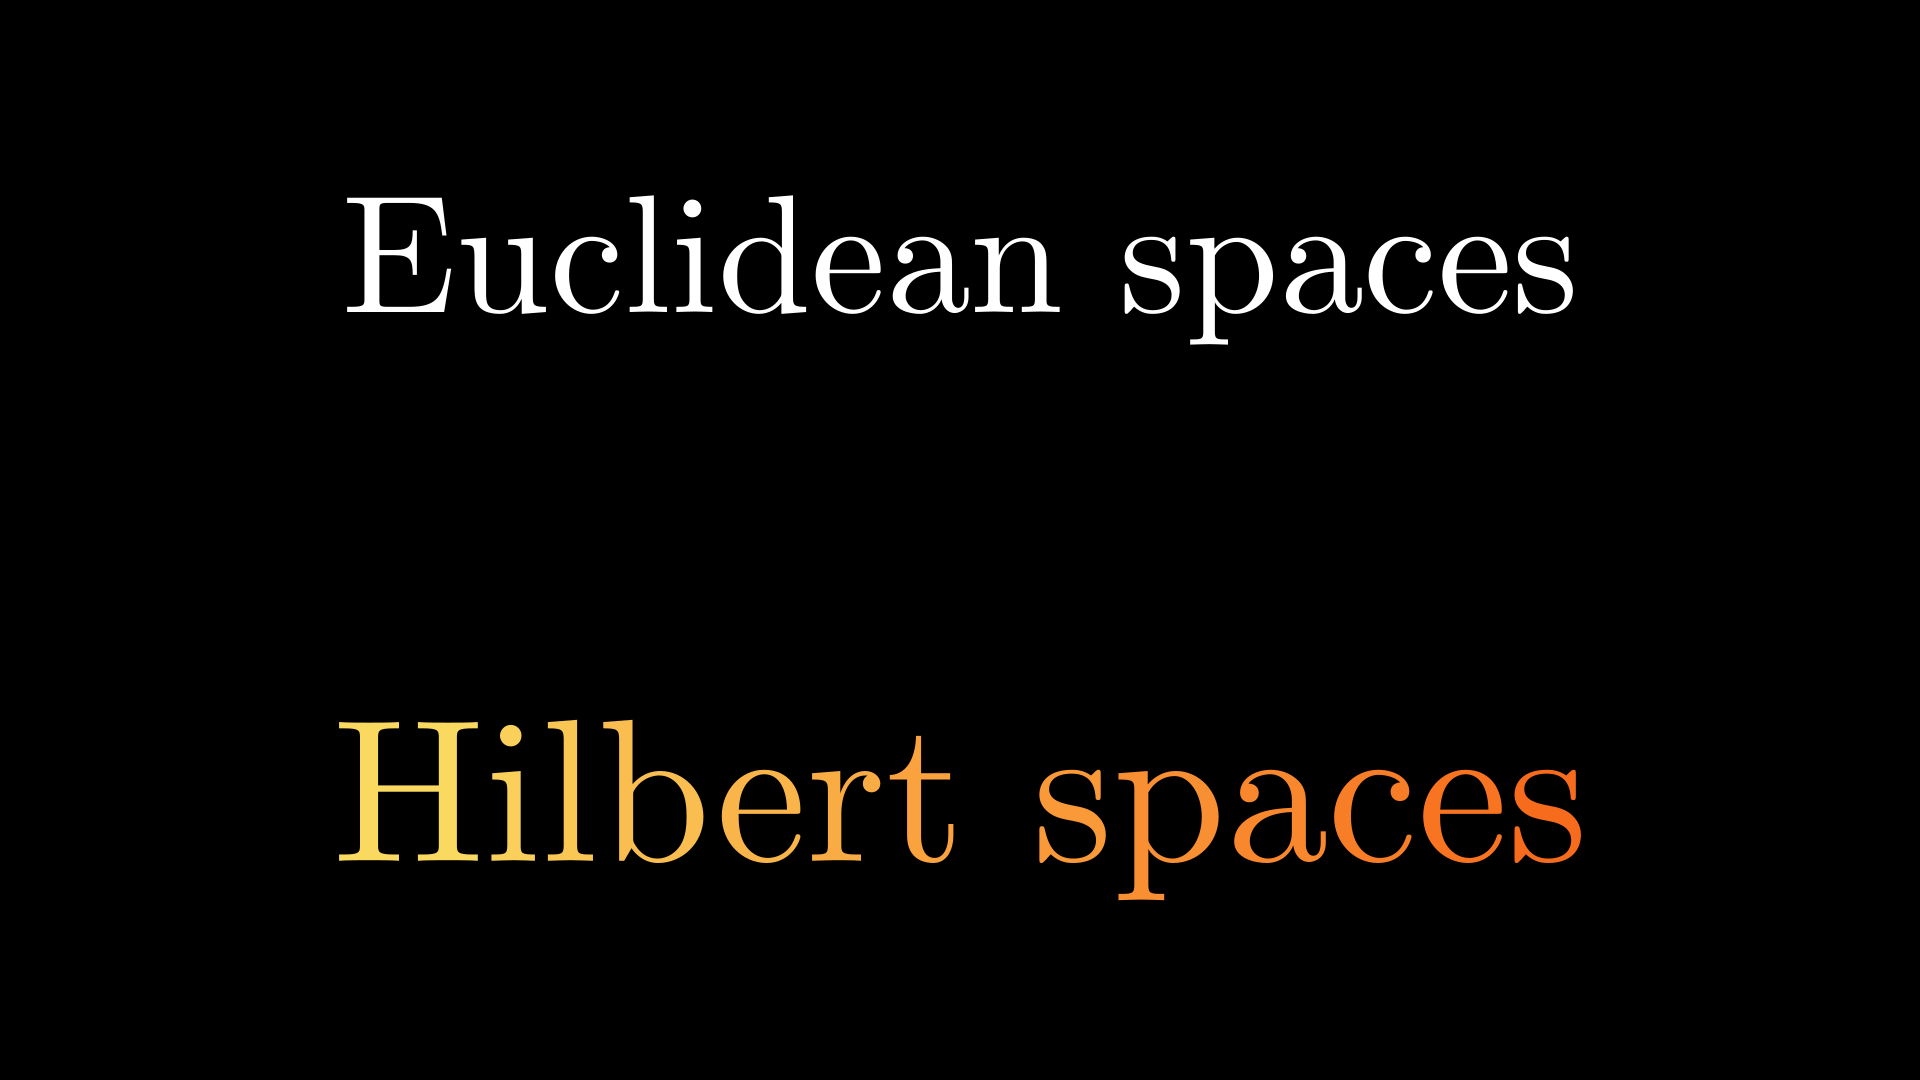

In [26]:
%%manim -qh Thumbnail

class Thumbnail(Scene):
    def construct(self):
        title = Tex("Hilbert spaces", font_size=145)
        title.set_color_by_gradient(*gradient_colors)
        title.move_to(DOWN*2)
        
        title2 = Tex("Euclidean spaces", font_size=120)
        #title2.set_color_by_gradient(*gradient_colors)
        title2.move_to(UP*2)
        
        self.add(title, title2)

Manim Community v0.18.1

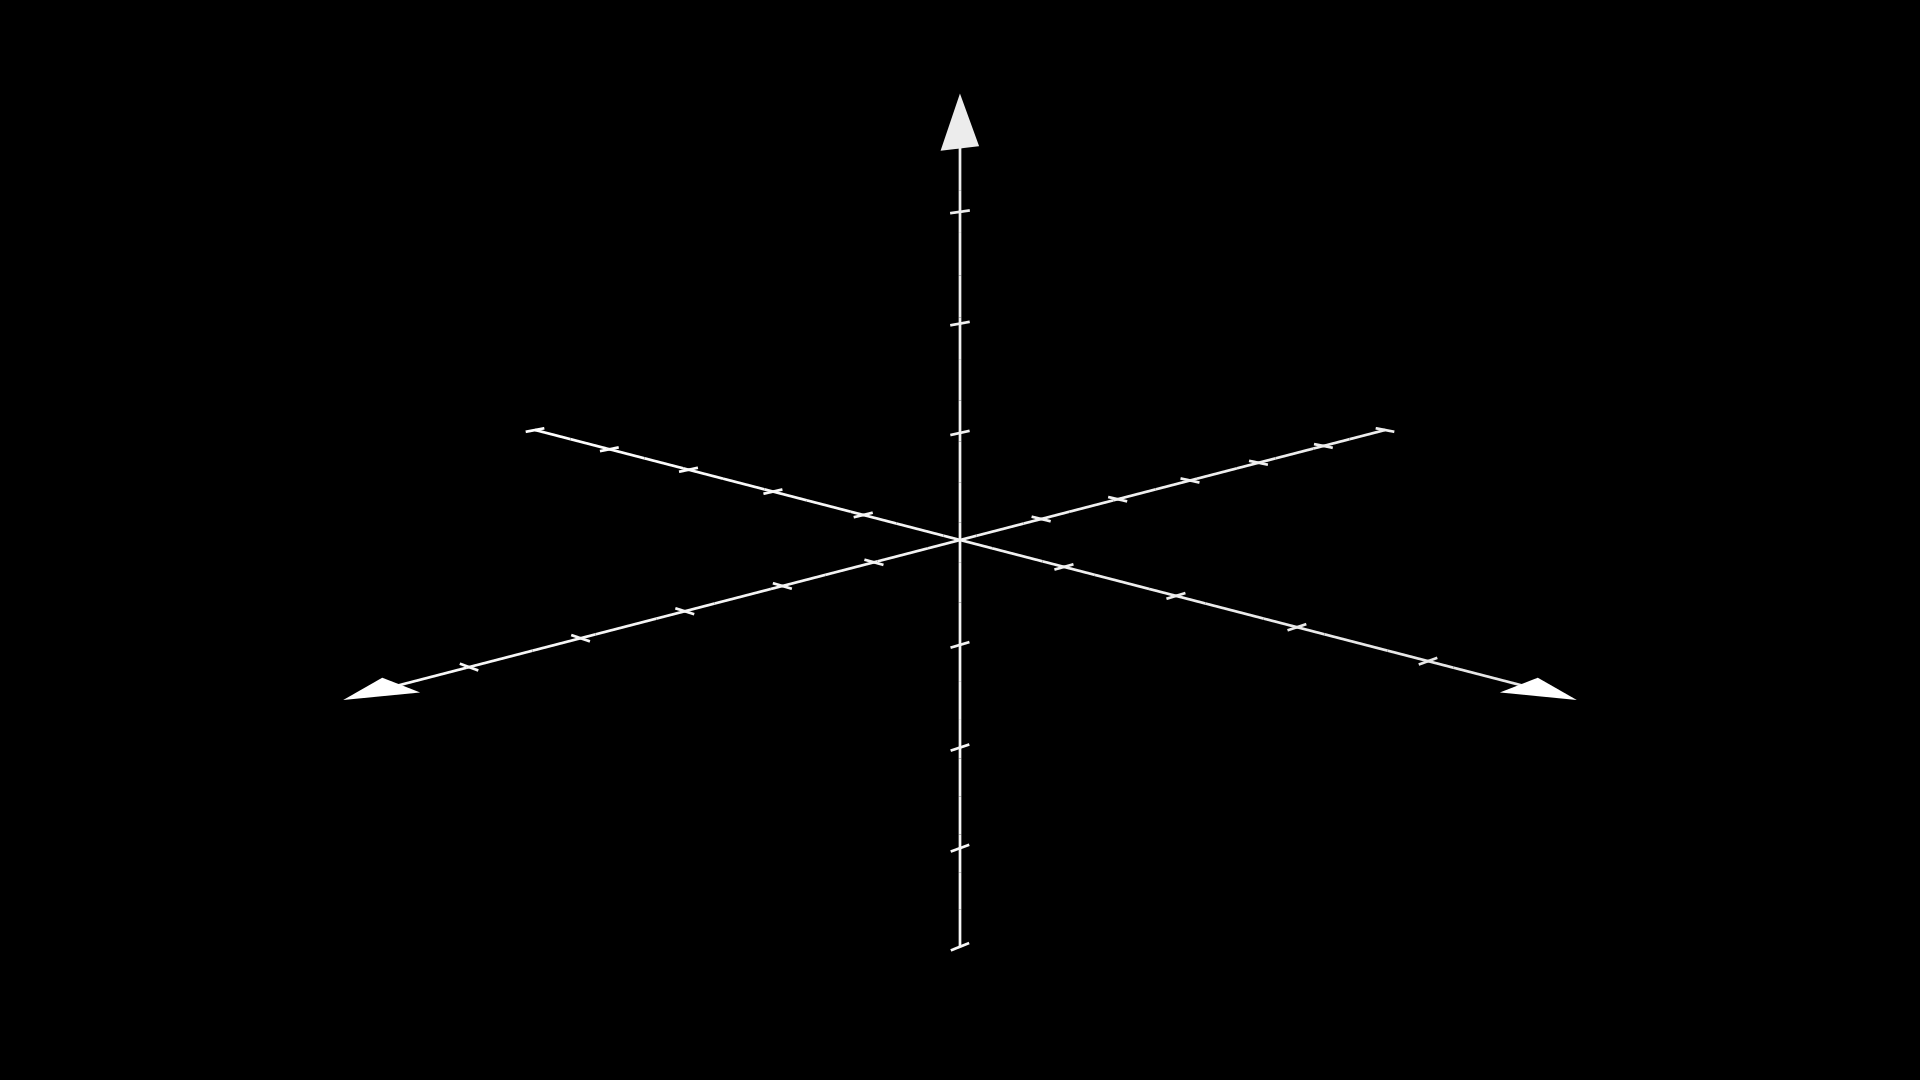

In [28]:
%%manim -qh ThreeD

class ThreeD(ThreeDScene):
    def construct(self):
        # Set up the 3D axes
        axes = ThreeDAxes()
        self.add(axes)

        # Define the line
        line = Line3D(
            start=axes.c2p(-2, -1, 1),  # Start point of the line
            end=axes.c2p(2, 1, 1),      # End point of the line
            color=BLUE
        )

        # Define the point
        point = Dot3D(
            point=axes.c2p(0, 0, 2),    # Coordinates of the point
            color=RED
        )

        # Define the plane as a polygon (quadrilateral)
        plane_polygon = Polygon(
            axes.c2p(-3, -3, -1),       # Bottom-left corner
            axes.c2p(1, -3, -1),        # Bottom-right corner
            axes.c2p(1, 1, -1),         # Top-right corner
            axes.c2p(-3, 1, -1),        # Top-left corner
            color=GREEN,
            fill_opacity=0.5
        )

        # Add the line, point, and polygon plane to the scene
        #self.add(line, point, plane_polygon)

        # Add a camera rotation for better visualization
        self.set_camera_orientation(phi=75 * DEGREES, theta=45 * DEGREES)
        


Manim Community v0.18.1

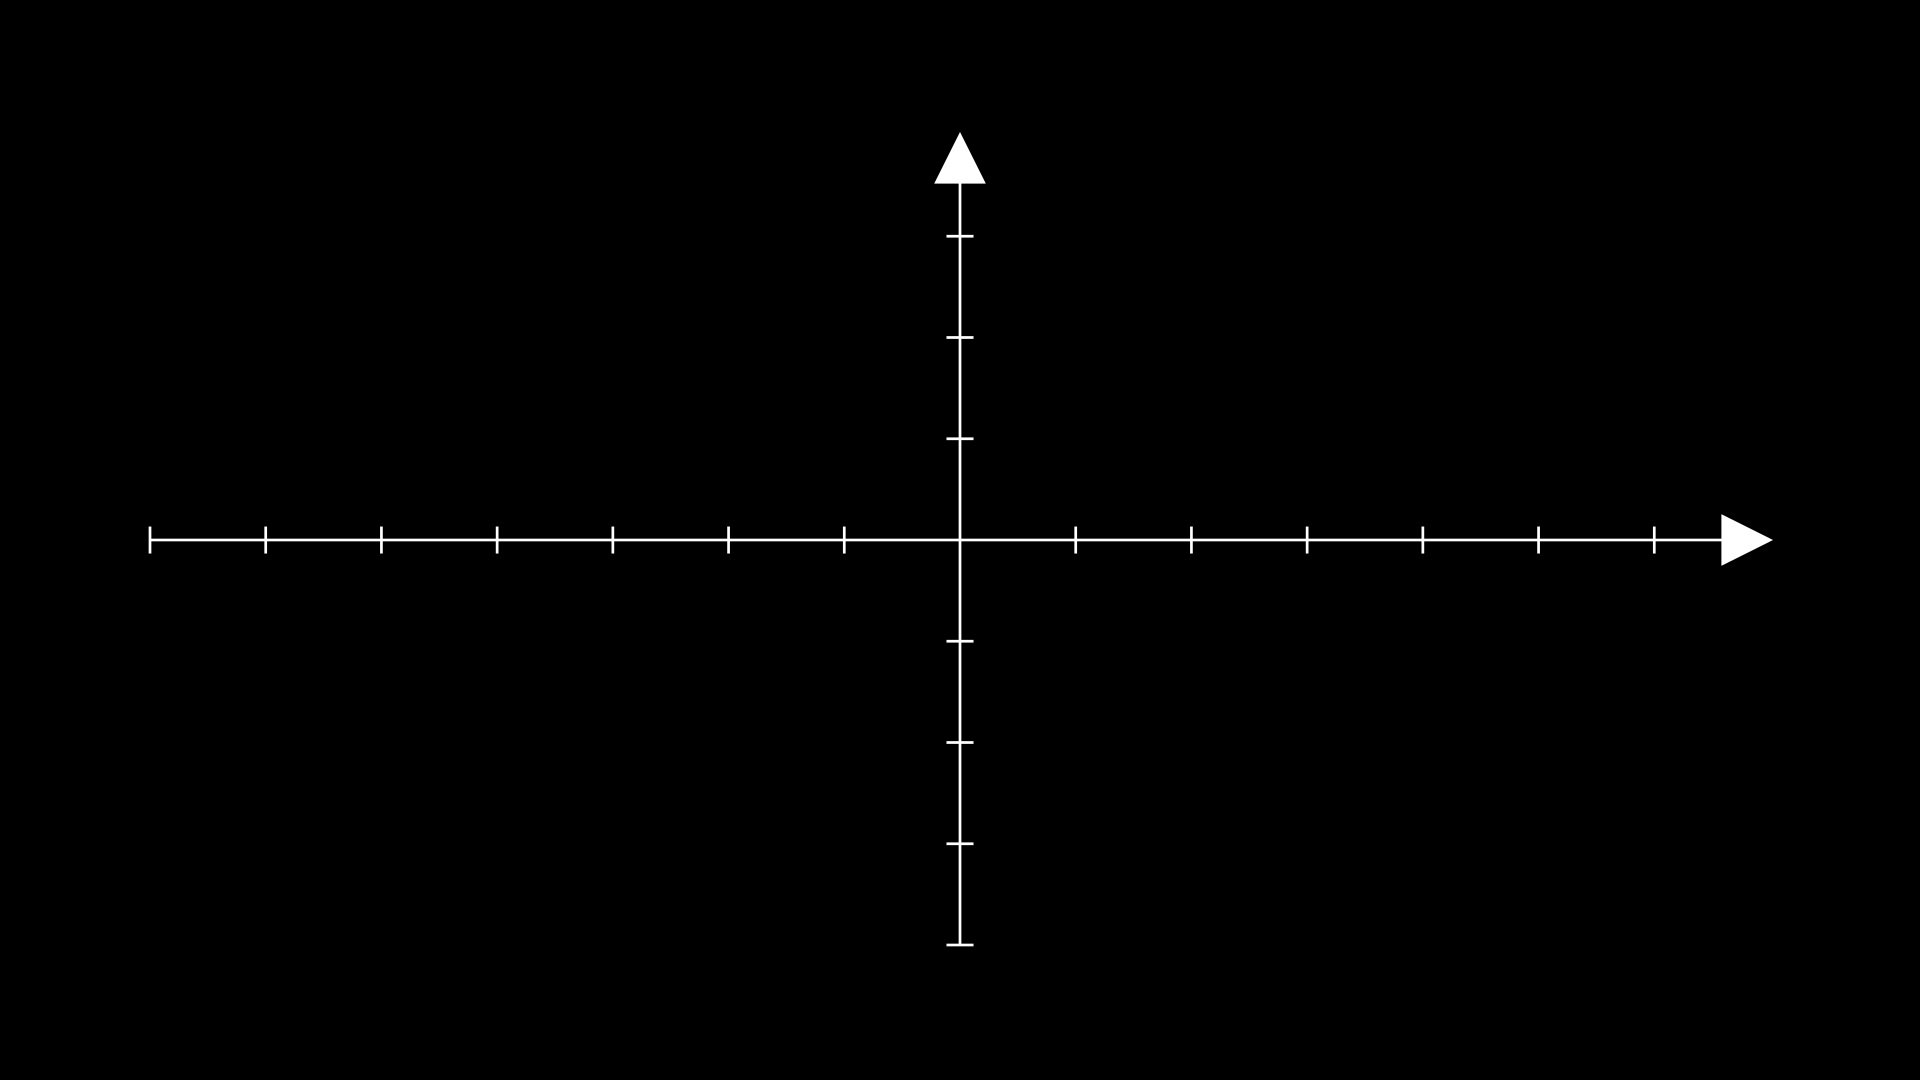

In [34]:
%%manim -qh TwoD

class TwoD(Scene):
    def construct(self):
        axes = Axes(
        )
        self.add(axes)

# Title

In [34]:
%%manim -qm S1

class S1(Scene):
    def construct(self):
        vec1 = Tex(r"$V$ real vector space, $n=\dim V < \infty$")
        vec1.move_to(UP*3.5)
        basis_vectors = VGroup(
            Vector([1.5, 0], color=RED),
            Vector([-1, 1.5], color=GREEN)
        )
        matrix = [[1.5, -1], [0, 1.5]]
        
        labels = VGroup(
            MathTex(r"\vec{b}_1", color=RED).next_to(basis_vectors[0].get_end(), DOWN),
            MathTex(r"\vec{b}_2", color=GREEN).next_to(basis_vectors[1].get_end(), LEFT)
        )

        plane = NumberPlane()
        plane.apply_matrix(matrix)
        plane.set_z_index(-1)

        iso = Tex(r"$\leadsto$ isomorphism $\varphi:V \xrightarrow{\sim} \mathbb{R}^n$")
        iso.move_to(DOWN*2.5)

        self.play(FadeIn(vec1))
        self.wait()
        self.play(Create(basis_vectors), Write(labels))
        self.wait()
        self.play(Create(plane))
        self.wait()
        self.play(Write(iso))
        self.wait()
        self.play(FadeOut(basis_vectors, labels, plane, iso))

        vec2 = Tex(r"with inner product $\langle \cdot,\cdot \rangle$")
        vec2.move_to(UP*2.7)
        basis_vectors2 = VGroup(
            Vector([1,0],color=RED),
            Vector([0,1],color=GREEN)
        )
        labels2 = VGroup(
            MathTex(r"\vec{b}_1", color=RED).next_to(basis_vectors2[0].get_end(), DOWN),
            MathTex(r"\vec{b}_2", color=GREEN).next_to(basis_vectors2[1].get_end(), LEFT)
        )
        plane2 = NumberPlane()
        plane2.set_z_index(-1)
        iso2 = Tex(r"$\leadsto$ isomorphism $\varphi:V \xrightarrow{\sim} \mathbb{R}^n$, \\$\langle v,w\rangle = \varphi(v)\cdot \varphi(w)$")
        iso2.move_to(DOWN*2.5)
        self.play(Write(vec2))
        self.wait()
        self.play(Create(basis_vectors2), Create(labels2))
        self.wait()
        self.play(Create(plane2))
        self.wait()
        self.play(Write(iso2))
        self.wait()
        self.play(FadeOut(vec1, vec2, basis_vectors2, labels2, plane2, iso2))

Manim Community v0.18.1

In [35]:
%%manim -qm S2

class S2(Scene):
    def construct(self):
        quest1 = Tex(r"Infinite-dimensional space $V$ with inner product $\langle\cdot,\cdot \rangle?$")
        quest1.move_to(UP*3)
        ortho = Tex(r"Orthonormal basis ", r"of $V$:", r" $\{u_\alpha \mid \alpha \in A\}$")
        ortho[0].set_color(RED)
        ortho.move_to(UP*2.3)
        maptex = Tex(r"injective mapping $\hat \cdot:V \hookrightarrow \ell^2(A)$, $\langle v,w\rangle = \langle \hat v, \hat w \rangle$")
        maptex.move_to(UP*1.3)
        hilb = Tex(r"If $\hat \cdot$ is surjective, V is called ", "Hilbert space")
        hilb[1].set_color_by_gradient(*gradient_colors)

        ex1 = Tex(r"e.g. $L^2(T)$ space of $2\pi$-periodic functions $f:\mathbb{R}\to\mathbb{C}$, \\such that $\int_0^{2\pi} |f(x)|^2\,dx < \infty$, is a ", "Hilbert space")
        ex1[1].set_color_by_gradient(*gradient_colors)
        ex1.move_to(DOWN*1.5)
        ex2 = MathTex(r"\hat f(n) = \frac{1}{2\pi} \int_0^{2\pi} f(x)e^{-inx} \,dx")
        ex2.move_to(DOWN*3)

        self.play(Write(quest1))
        self.wait()
        self.play(FadeIn(ortho))
        self.wait()
        self.play(FadeIn(maptex))
        self.wait()
        self.play(Write(hilb))
        self.wait()
        self.play(FadeIn(ex1))
        self.wait()
        self.play(Write(ex2))
        self.wait()
        self.play(FadeOut(quest1, ortho, maptex, hilb, ex1, ex2))

Manim Community v0.18.1

In [39]:
%%manim -qm S3

class S3(Scene):
    def construct(self):
        def1 = Tex(r"Let $V$ be a real vector space. ", r"An ", r"inner product", r" on $V$ \\is a map $\langle\cdot,\cdot\rangle: V\times V \to \mathbb{R}$ such that")
        def1[2].set_color_by_gradient(*gradient_colors)
        def1.move_to(UP*2.5)
        def2 = Tex(r"""\begin{itemize} \item (Linearity in first argument): \\$\langle ax+by,z \rangle = a\langle x,z \rangle + b \langle y,z \rangle $
                   \item (Symmetry): \\$\langle x,y \rangle = \langle y,x \rangle$
                   \item (Positive-definitness): \\$\langle x,x \rangle > 0 \text{ for } x \ne 0$
                   \end{itemize}""")
        def2.move_to(DOWN)
        self.play(Write(def1[0]))
        self.wait()
        self.play(Write(def1[1:]))
        self.play(Write(def2))
        self.wait()
        self.play(FadeOut(def1, def2))

Manim Community v0.18.1

In [37]:
%%manim -qm S4

class S4(Scene):
    def construct(self):
        norm1 = Tex(r"Induced norm: $\|x\| = \sqrt{\langle x,x \rangle}$")
        norm1.move_to(UP*3)
        norm2 = Tex(r"Cauchy-Schwarz inequality", r": $|\langle x,y\rangle| \le \|x\|\cdot \|y\|$")
        norm2[0].set_color_by_gradient(*gradient_colors)
        norm2.move_to(UP*2)
        angle = Tex(r"Angle $\theta$ between two vectors $x,y$:")
        angle.move_to(UP*0.5)
        angle2 = MathTex(r"\theta = \arccos{\frac{\langle x,y \rangle}{\|x\|\|y\|}}")
        angle2.move_to(DOWN*0.5)
        anglevec = VGroup(
            Vector([1.5, 1], color=BLUE),
            Vector([1,-1], color=GREEN)
        )
        anglevec.move_to(DOWN*0.5 + LEFT*5)
        angleill = Angle(anglevec[0], anglevec[1], radius=0.7, other_angle=True, color=YELLOW)
        angleill_label = MathTex(r"\theta").move_to(angleill.get_center() + LEFT*0.15)
        ortho = Tex(r"$x\perp y \Leftrightarrow \langle x,y \rangle = 0$")
        ortho.move_to(DOWN*2)

        self.play(Write(norm1))
        self.wait()
        self.play(Write(norm2))
        self.wait()
        self.play(FadeIn(angle), Create(anglevec))
        self.play(Create(angleill), Write(angleill_label))
        self.wait()
        self.play(Write(angle2))
        self.wait()
        self.play(Write(ortho))
        self.wait()        
        self.play(FadeOut(norm1, norm2, angle, anglevec, angleill, angleill_label, angle2, ortho))

Manim Community v0.18.1

In [80]:
%%manim -qm S5

class S5(Scene):
    def construct(self):
        ex1 = Tex(r"$\mathbb{R}^n$ with $\langle x, y\rangle = \sum_{i=1}^n x_iy_i$")
        ex1.move_to(UP*2)
        ex2 = Tex(r"$\ell^2(\mathbb{N})$ space of real sequences such that $\sum_{i=0}^\infty x_n^2 < \infty$ \\with $\langle x,y \rangle = \sum_{i=0}^\infty x_iy_i$")
        ex2.move_to(UP*0.5)
        ex3 = Tex(r"$C^2_{[a,b]}$ space of continuous functions $f:[a,b] \to \mathbb{R}$ \\with $\langle f,g \rangle = \int_a^b f(x)g(x)\,dx$")
        ex3.move_to(DOWN*1.5)

        self.play(Write(ex1))
        self.wait()
        self.play(Write(ex2))
        self.wait()
        self.play(Write(ex3))
        self.wait()
        self.play(FadeOut(ex1, ex2, ex3))

Manim Community v0.18.1

In [40]:
%%manim -qm S6

class S6(Scene):
    def construct(self):
        def1 = Tex(r"Let $V$ be a complex vector space. ", r"An ", r"inner product", r" on $V$ \\is a map $\langle\cdot,\cdot\rangle: V\times V \to \mathbb{C}$ such that")
        def1.move_to(UP*2.5)
        def1[2].set_color_by_gradient(*gradient_colors)
        def2 = Tex(r"""\begin{itemize} \item (Linearity in first argument): \\$\langle ax+by,z \rangle = a\langle x,z \rangle + b \langle y,z \rangle $
                   \item (Conjugate Symmetry): \\$\langle x,y \rangle = \overline{\langle y,x \rangle}$
                   \item (Positive-definitness): \\$\langle x,x \rangle > 0 \text{ for } x \ne 0$
                   \end{itemize}""")
        def2.move_to(DOWN)
        self.play(Write(def1[0]))
        self.wait()
        self.play(Write(def1[1:]))
        self.play(Write(def2))
        self.wait()
        self.play(FadeOut(def1, def2))

Manim Community v0.18.1

In [83]:
%%manim -qm S7

class S7(Scene):
    def construct(self):
        ex1 = Tex(r"$\mathbb{C}^n$ with $\langle x, y\rangle = \sum_{i=1}^n x_i\overline{y_i}$")
        ex1.move_to(UP*2)
        ex2 = Tex(r"$\ell^2(\mathbb{N})$ space of complex sequences such that $\sum_{i=0}^\infty |x_n|^2 < \infty$ \\with $\langle x,y \rangle = \sum_{i=0}^\infty x_i\overline{y_i}$")
        ex2.move_to(UP*0.5)
        ex3 = Tex(r"$L^2(T)$ space of functions $f:T \to \mathbb{C}$ such that $\int_T f \,d\mu < \infty$ \\with $\langle f,g \rangle = \int_T f \overline{g} \,d\mu = \frac{1}{2\pi} \int_0^{2\pi} f(x)\overline{g(x)} \, dx$")
        ex3.move_to(DOWN*1.5)

        self.play(Write(ex1))
        self.wait()
        self.play(Write(ex2))
        self.wait()
        self.play(Write(ex3))
        self.wait()
        self.play(FadeOut(ex1, ex2, ex3))

Manim Community v0.18.1

In [44]:
%%manim -ql S8

class S8(Scene):
    def construct(self):
        ortho = Tex(r"An ", r"orthonormal set", r" is a set of vectors\\ that are mutually orthogonal and of unit length.")
        ortho[1].set_color(RED)
        ortho.move_to(UP*3)
        quest = Tex(r"How to describe $V$ by a orthonormal set $\{u_\alpha \mid \alpha \in A\}$?")
        quest.move_to(UP*1.5)
        self.play(Write(ortho))
        self.wait()
        self.play(FadeIn(quest))
        self.wait()
        self.play(FadeOut(ortho), quest.animate.shift(UP*1.5))
        self.wait()
        fin1 = Tex(r"If $A$ is finite, what is the best way to\\ approximate a vector $x$ with linear combinations of $u_\alpha$?")
        fin1.move_to(UP*1.5)
        fin2 = Tex(r"$\sum_{\alpha \in A} \langle x, u_\alpha\rangle u_\alpha$ is optimal")
        #fin2.move_to(UP*0.5)
        self.play(Write(fin1))
        self.wait()
        self.play(Write(fin2))
        self.wait()
        
        inf1 = Tex(r"If $A$ is infinite, does $\sum_{\alpha \in A} \langle x,u_\alpha \rangle u_\alpha$ converge?")
        inf1.move_to(DOWN*1.5)
        inf2 = Tex(r"Bessel's inequality", ": ", r"$\sum_{\alpha \in A} |\langle x,u_\alpha \rangle|^2 \le \|x\|^2$")
        inf2[0].set_color_by_gradient(*gradient_colors)
        inf2.move_to(DOWN*2.5)
        self.play(Write(inf1))
        self.wait()
        self.play(Write(inf2))
        self.wait()
        self.play(FadeOut(quest, fin1, fin2, inf1, inf2))

        cho1 = Tex(r"Under Axiom of Choice, there is a maximal orthonormal set\\ $\{u_\alpha \mid \alpha \in A\}$, so there is no $x \in V$\\ such that $x \perp u_\alpha$ for all $\alpha \in A$")
        cho1.move_to(UP*2.5)
        cho2 = Tex(r"$\leadsto$", r" orthonormal basis", r" $\{u_\alpha \mid \alpha \in A\}$")
        cho2[1].set_color(RED)
        cho2.move_to(UP*1)

        self.play(FadeIn(cho1))
        self.wait()
        self.play(Write(cho2))
        self.wait()
        self.play(FadeOut(cho1, cho2[0]), cho2[1:].animate.shift(UP*2))

        bas1 = Tex(r"$x = \sum_{\alpha \in A} \langle x, u_\alpha \rangle u_\alpha$")
        bas1.move_to(UP*2)
        bas2 = Tex(r"Fourier coefficients: $\hat x(\alpha) = \langle x,u_\alpha \rangle$")
        bas2.move_to(UP)
        base12 = Tex(r"$x = \sum_{\alpha \in A} \hat x(\alpha) u_\alpha$ (Fourier series)")
        base12.move_to(UP*2)

        self.play(Write(bas1))
        self.wait()
        self.play(Write(bas2))
        self.wait()
        self.play(Transform(bas1, base12))

        pars1 = MathTex(r"\text{Parseval's identity}", r": \langle x,y \rangle = \sum_{\alpha \in A} \hat x(\alpha) \overline{\hat y(\alpha)}", r"= \langle \hat x, \hat y \rangle")
        pars1[0].set_color_by_gradient(*gradient_colors)
        pars1.move_to(DOWN*0.5)
        pars2 = Tex(r"$\leadsto$ injective mapping $\hat \cdot: V \hookrightarrow \ell^2(A)$")
        pars2.move_to(DOWN*1.5)
        hilb1 = Tex(r"A ", r"Hilbert space", r" is a complete inner product space")
        hilb1[1].set_color_by_gradient(*gradient_colors)
        hilb1.move_to(DOWN*3)

        self.play(Write(pars1[0:2]))
        self.wait()
        self.play(Write(pars2), FadeIn(pars1[2]))
        self.wait()
        self.play(Write(hilb1))
        self.wait()
        self.play(FadeOut(cho2[1:], bas1, bas2, pars1, pars2, hilb1))
        

Manim Community v0.18.1

In [45]:
%%manim -qm S9

class S9(Scene):
    def legendre_polynomials(self, x, n):
        if n == 0:
            return np.ones_like(x)
        elif n == 1:
            return x
        else:
            Pn_1 = x  # P1(x)
            Pn_2 = np.ones_like(x)  # P0(x)
            for k in range(2, n + 1):
                Pn = ((2 * k - 1) * x * Pn_1 - (k - 1) * Pn_2) / k
                Pn_2, Pn_1 = Pn_1, Pn
            return Pn
        
    def construct(self):
        con1 = Tex(r"Legendre polynomials", r" in $C^2_{[-1,1]}$")
        con1[0].set_color_by_gradient(*gradient_colors)
        con1.move_to(UP*3.5)
        self.play(Write(con1))
        hilb1 = Tex(r"Not a Hilbert space")
        hilb1.move_to(DOWN*3.5)
        
        axes = Axes(
            x_range=[-1.2, 1.2, 0.2],
            y_range=[-1.5, 1.5, 0.5],
            tips=False,
            axis_config={"include_numbers": True},
        ).add_coordinates()

        
        # Add axes to the scene
        self.play(Create(axes))
        
        # Define the x values
        x_values = np.linspace(-1, 1, 200)

        # Define colors for the polynomials
        colors = [RED, GREEN, BLUE, ORANGE, PURPLE]

        # Plot and animate the first few Legendre polynomials
        for n, color in enumerate(colors):
            y_values = self.legendre_polynomials(x_values, n)
            graph = axes.plot_line_graph(
                x_values, y_values, add_vertex_dots=False, line_color=color
            )
            
            label = MathTex(f"P_{{{n}}}(x)").next_to(graph, UP).set_color(color)
            
            self.play(Create(graph))
            self.wait(1)
            

        # Hold the final scene for a moment
        self.wait(2)
        self.play(Write(hilb1))
        self.wait()
        

Manim Community v0.18.1

In [47]:
%%manim -qm S10

class S10(Scene):
    def construct(self):
        # Title
        title = Tex(r"Orthonormal Basis", r": $\{e^{inx} \mid n\in\mathbb{Z} \}$ in $L^2(T)$")
        title[0].set_color_by_gradient(*gradient_colors)
        self.play(Write(title))
        self.wait(1)
        self.play(title.animate.to_edge(UP))

        # Plot setup
        axes = Axes(
            x_range=[0, TAU, PI / 2], y_range=[-1.5, 1.5, 0.5],
            x_length=8, y_length=4,
            tips=False
        )
        labels = axes.get_axis_labels(x_label="x", y_label="f(x)")

        # Function to approximate
        square_wave = axes.plot(
            lambda x: np.sign(np.sin(x)),
            color=YELLOW,
            stroke_width=2,
            use_smoothing=False
        )

        self.play(Create(axes))
        self.play(Create(square_wave))
        self.wait(1)

        # Show basis components
        components = VGroup()
        for n, color in zip(range(1, 5), [BLUE, GREEN, RED, PURPLE]):
            sine_wave = axes.plot(
                lambda x: (4 / (n * PI)) * np.sin(n * x) if n % 2 != 0 else 0,
                color=color,
                stroke_width=2
            )
            components.add(sine_wave)
            sine_label = MathTex(f"\frac{{4}}{{{n}\pi}}\sin({n}x)").scale(0.8).next_to(axes, DOWN)
            
            self.play(Create(sine_wave))
            self.wait(0.5)

        self.wait(1)

        # Combine components
        self.play(FadeOut(components))
        combined = axes.plot(
            lambda x: sum((4 / (n * PI)) * np.sin(n * x) for n in range(1, 5, 2)),
            color=BLUE,
            stroke_width=2,
        )
        self.play(Create(combined))
        self.wait(2)

        # Cleanup
        self.play(FadeOut(combined), FadeOut(square_wave), FadeOut(axes))

        # Show orthonormality
        fou1 = MathTex(r"\hat f(n) = \frac{1}{2\pi} \int_0^{2\pi} f(x) e^{-inx}\, dx")
        fou1.move_to(UP*1.5)
        fou2 = MathTex(r"s_n(f)(x) = \sum_{k=-n}^n \hat f(k) e^{ikx}")
        fou3 = MathTex(r"\|f - s_n(f)\|_2 \xrightarrow{n\to\infty} 0")
        fou3.move_to(DOWN*1.5)
        fou4 = Tex(r"$L^2(T)$ is a ", r"Hilbert space")
        fou4[1].set_color_by_gradient(*gradient_colors)
        fou4.move_to(DOWN*3)
        
        self.play(Write(fou1))
        self.wait()
        self.play(Write(fou2))
        self.wait()
        self.play(Write(fou3))
        self.wait()
        self.play(Write(fou4))
        self.wait()
        self.play(FadeOut(title, fou1, fou2, fou3, fou4))


Manim Community v0.18.1